### Animal Faces Classification Task:Understanding CNN

In [ ]:
# Import necessary libraries
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout , Input , Flatten , BatchNormalization
from tensorflow.keras.regularizers import l1, l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import kagglehub
from skimage.feature import hog
from skimage.color import rgb2gray
from skimage.transform import resize

# Set random seed for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

In [ ]:
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import kagglehub

# Download dataset
path = kagglehub.dataset_download("andrewmvd/animal-faces")
print("Path to dataset files:", path)

# Define paths
data_dir = os.path.join(path, 'afhq')
train_dir = os.path.join(data_dir, 'train')
test_dir = os.path.join(data_dir, 'val')

# ImageDataGenerators
train_datagen = ImageDataGenerator(rescale=1./255)
test_val_datagen = ImageDataGenerator(rescale=1./255)

# Train generator
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(128, 128),
    batch_size=128,
    class_mode='categorical',
)

test_generator = test_val_datagen.flow_from_directory(
    test_dir,
    target_size=(128, 128),
    class_mode='categorical'
)


print(f"Train samples: {train_generator.samples}")
print(f"Test samples: {test_generator.samples}")


Using Colab cache for faster access to the 'animal-faces' dataset.
Path to dataset files: /kaggle/input/animal-faces
Found 14630 images belonging to 3 classes.
Found 1500 images belonging to 3 classes.
Train samples: 14630
Test samples: 1500


(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)


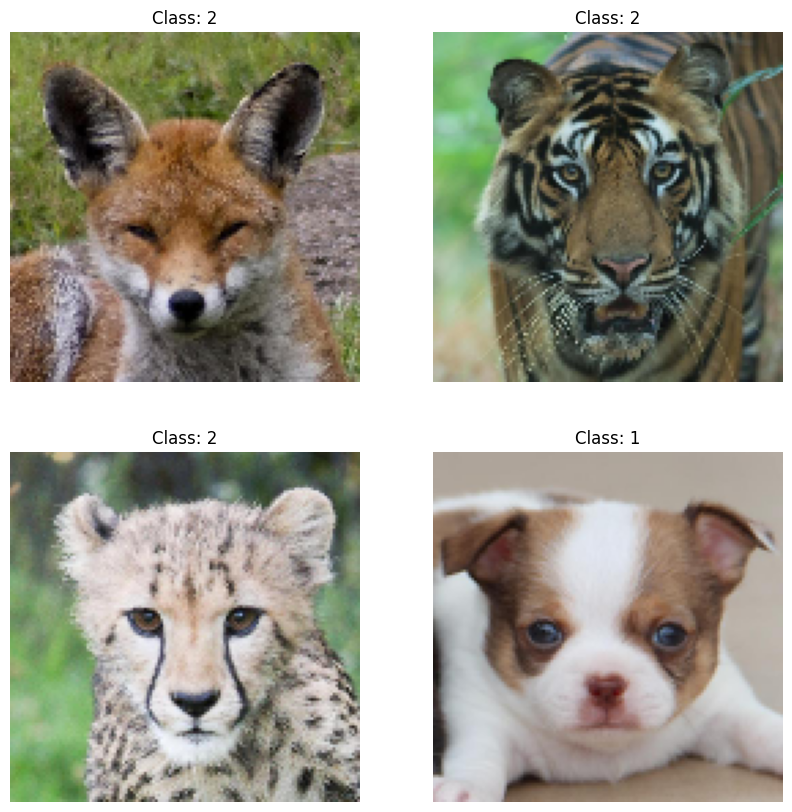

In [ ]:
# Optional: Visualize a batch of images to confirm loading
import matplotlib.pyplot as plt

images, labels = next(train_generator)  # Get one batch
plt.figure(figsize=(10,10))
for i in range(4):  # Show first 4 images
    plt.subplot(2, 2, i+1)
    print(images[i].shape)
    plt.imshow(images[i])
    plt.title(f'Class: {labels[i].argmax()}')
    plt.axis('off')
plt.show()

In [ ]:
# Function to plot training history (accuracy and loss curves)
def plot_history(history, title):
    plt.figure(figsize=(12, 4))

    # Plot accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    if 'val_accuracy' in history.history:
        plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.title(f'{title} - Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    # Plot loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    if 'val_loss' in history.history:
        plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title(f'{title} - Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()



# X_test = []
# y_test = []
# print(range(len(test_generator)))
# for i in range(len(test_generator)):
#     #append images and labels from each batch
#     images, labels = next(test_generator)
#     images = extract_hog_features(images)
#     X_test.append(images)
#     y_test.append(labels)
# X_test = np.vstack(X_test)
# y_test = np.vstack(y_test)

# Function to evaluate on test set
def evaluate_model(model):
    test_loss, test_acc = model.evaluate(test_generator)
    print(f'Test Accuracy: {test_acc:.4f}')
    return test_acc

Epoch 1/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 492s 4s/step - accuracy: 0.6439 - loss: 0.9156
Epoch 2/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 488s 4s/step - accuracy: 0.8474 - loss: 0.3927
Epoch 3/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 484s 4s/step - accuracy: 0.8765 - loss: 0.3184
Epoch 4/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 493s 4s/step - accuracy: 0.9054 - loss: 0.2526
Epoch 5/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 468s 4s/step - accuracy: 0.9191 - loss: 0.2132
Epoch 6/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 478s 4s/step - accuracy: 0.9299 - loss: 0.1939
Epoch 7/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 499s 4s/step - accuracy: 0.9422 - loss: 0.1616
Epoch 8/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 480s 4s/step - accuracy: 0.9516 - loss: 0.1410
Epoch 9/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 467s 4s/step - accuracy: 0.9546 - loss: 0.1293
Epoch 10/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 482s 4s/step - accuracy: 0.9592 - loss: 0.1186


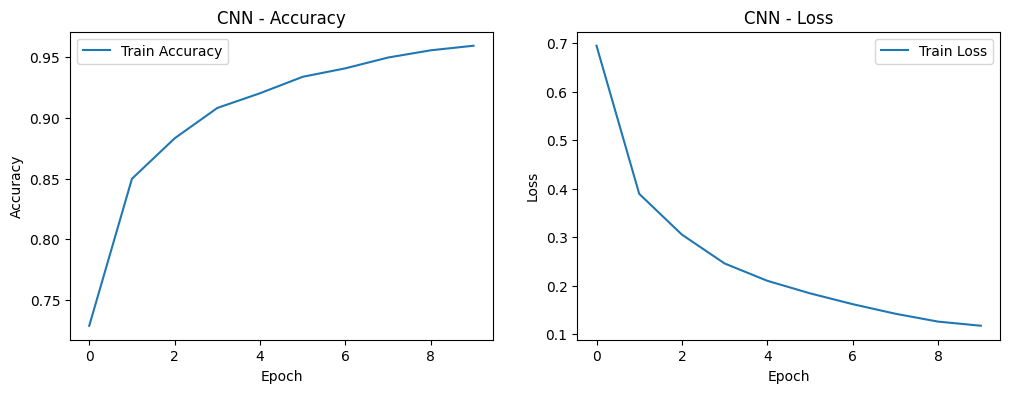

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


47/47 ━━━━━━━━━━━━━━━━━━━━ 15s 299ms/step - accuracy: 0.9185 - loss: 0.2052
Test Accuracy: 0.9187


0.918666660785675

In [ ]:

model = Sequential([
      Input(shape=(128, 128, 3)),
      Conv2D(filters=32 , kernel_size=(3,3) , activation="relu") ,
      BatchNormalization(),
      MaxPooling2D(pool_size=(2, 2)),
      Dropout(rate=0.25),
      Flatten(),
      Dense(256 , "relu"),
      BatchNormalization(),
      # Dense(128 , "relu"),
      # BatchNormalization(),
      # Dense(64, "relu"),
      Dropout(rate=0.3),
      Dense(3 , "softmax")
    ])

learning_rate = 0.001
optimizer = tf.keras.optimizers.SGD(learning_rate=learning_rate)
model.compile(optimizer=optimizer,loss="categorical_crossentropy" , metrics=['accuracy'])
history = model.fit(
    train_generator, epochs=10
  )
plot_history(history,"CNN")
evaluate_model(model)